# TER — literary age prediction (1D CNN)

Run this notebook on a **Kaggle GPU** session (Accelerator: GPU).

## What to upload as Kaggle Dataset(s)

Create a **single zip** (or folder) whose **root** matches your machine repo:

- `src/` — Python package  
- `lists/` — lexicons, stopwords, accented chars (paths used by `config.py`)  
- `corpus_age_etudiant/` — `.txt` files  

Add that dataset to this notebook. Kaggle may mount it under `/kaggle/input/datasets/...` — the next cell **auto-finds** the folder that contains `src/`, `lists/`, and `corpus_age_etudiant/`. Optionally set `DATASET_HINT` to narrow the search (e.g. `"datasets/my-dataset-slug"`).

**Checkpoints** and TensorBoard logs go to `/kaggle/working/experiments` (writable). The read-only input mount is only for code + data.

After training, run the **visualization** cells to plot loss, accuracy, and MAE curves from those logs (and save `training_curves.png` under `/kaggle/working` on Kaggle).

### Kaggle upload errors (`'` / `"` in filenames)

Kaggle rejects **ASCII apostrophe and quote** in paths. French titles like `l'oubli` trigger that. From the repo root run:

`python scripts/prepare_kaggle_dataset.py --out path/to/kaggle_bundle --zip-output TER_Kaggle.zip`

Use **`--zip-output`** (Python `zipfile`): on Windows, PowerShell `Compress-Archive` puts **backslashes** inside the zip, and Kaggle reports a forbidden `\` in names. If upload still fails, add `--ascii-safe`. Avoid a double `corpus_age_etudiant/corpus_age_etudiant/` nest inside the zip.

In [1]:
import os
import sys
from pathlib import Path

# Optional: restrict search under /kaggle/input (e.g. "datasets/ter-kaggle-bundle"). None = search all.
DATASET_HINT = None

INPUT = Path("/kaggle/input")
IS_KAGGLE = INPUT.exists()


def find_project_root(search_under: Path) -> Path | None:
    """Directory that contains src/, lists/, corpus_age_etudiant/ (shallowest match)."""
    if not search_under.is_dir():
        return None
    hits: list[tuple[int, Path]] = []
    for src in search_under.rglob("src"):
        if not src.is_dir() or src.name != "src":
            continue
        root = src.parent
        if (root / "lists").is_dir() and (root / "corpus_age_etudiant").is_dir():
            depth = len(src.relative_to(search_under).parts)
            hits.append((depth, root))
    if not hits:
        return None
    hits.sort(key=lambda x: x[0])
    return hits[0][1]


if IS_KAGGLE:
    search_root = (INPUT / DATASET_HINT) if DATASET_HINT else INPUT
    DATASET_ROOT = find_project_root(search_root)
    if DATASET_ROOT is None:
        top = [p.name for p in INPUT.iterdir() if p.is_dir()]
        raise FileNotFoundError(
            f"No folder with src/, lists/, corpus_age_etudiant/ under {search_root}. "
            f"Top-level /kaggle/input dirs: {top}. Add the dataset to the notebook or set DATASET_HINT."
        )
    sys.path.insert(0, str(DATASET_ROOT.resolve()))
    os.environ["TER_CHECKPOINT_DIR"] = "/kaggle/working/experiments"
    os.makedirs(os.environ["TER_CHECKPOINT_DIR"], exist_ok=True)
else:
    DATASET_ROOT = Path.cwd()
    sys.path.insert(0, str(DATASET_ROOT.resolve()))

print("PROJECT path on sys.path:", DATASET_ROOT)
print("Checkpoints:", os.environ.get("TER_CHECKPOINT_DIR", "(default: repo/experiments)"))

PROJECT path on sys.path: /kaggle/input/datasets/ayachihoub/ter-kaggle
Checkpoints: /kaggle/working/experiments


In [2]:
# Extra Python deps (Kaggle already ships PyTorch with CUDA — do not reinstall torch here)
!pip install -q tqdm scikit-learn pandas numpy matplotlib seaborn spacy fpdf2 tensorboard
!python -m spacy download fr_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 77.0 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import os

# Set before import: hide per-batch tqdm bars so Kaggle/Jupyter shows mostly epoch lines (acc / loss).
# Remove this line if you want full batch progress bars.
os.environ["TER_EPOCH_ONLY"] = "1"

from src.training.train import main

main()

2026-04-14 16:08:19.180035: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776182899.379532      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776182899.434267      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776182899.916550      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776182899.916598      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776182899.916601      55 computation_placer.cc:177] computation placer alr

Loading configurations...
🚀 SUCCESS: NVIDIA GPU detected! Training on: Tesla T4

Loading the full corpus...

📊 Data Distribution:
   - Train : 1881 texts
   - Val   : 333 texts
   - Test  : 246 texts

Building Datasets (Feature extraction in progress)...
Computing global word frequencies from training corpus ...
  → 327829 unique words, 162212066 total tokens
Fitting global StandardScaler on training features ...
  → fitted on 157480726 token-rows (train only)
  → mean (first 3): [1.93057564e+06 3.91060753e+00 2.61878219e-01]
  → scale (first 3): [3.06592081e+06 2.69933295e+00 8.10220908e-01]
Building train dataset (1881 texts, seq_len=5000, stride=5000) ...
  → 31497 train samples
Building val/test dataset (333 texts, seq_len=5000, stride=5000) ...
  → 5724 samples

=== Global normalization (sample windows) ===
First train window: mean=-0.0275, std=0.9524 (per-window, not full train set)
First val window:   mean=0.0044, std=1.0177


Starting training loop...
Epoch [1/50] | Train Loss:

## Training curves (after `main()`)

The next cell reads **TensorBoard** scalar logs from `tensorboard_logs/` (same folder `train.py` writes to) and plots loss, accuracy, and MAE for train vs validation. Run it only **after** training has finished.

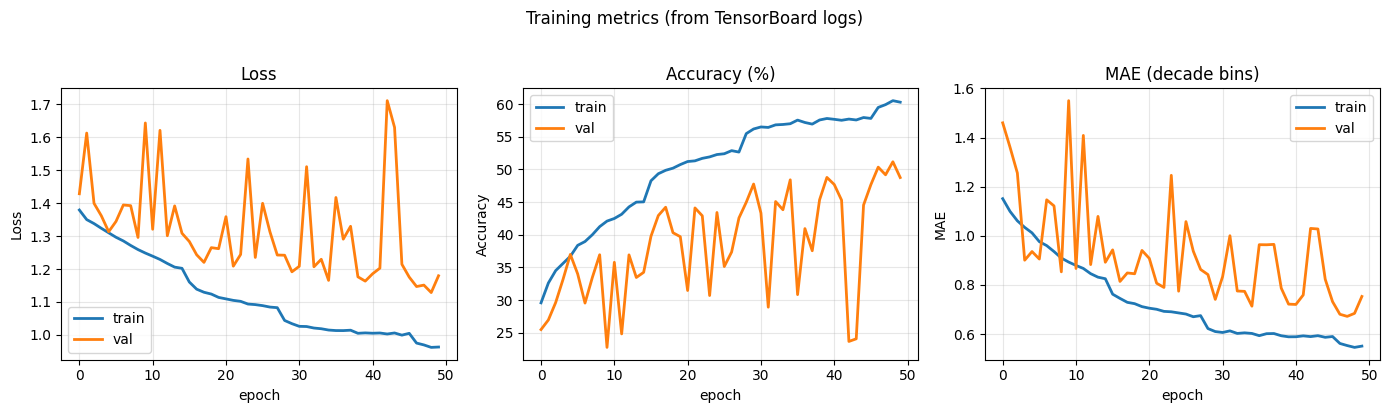

Saved figure: /kaggle/working/training_curves.png


In [4]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Same experiment root as training (Kaggle: TER_CHECKPOINT_DIR; else repo experiments/)
try:
    _root = Path(os.environ["TER_CHECKPOINT_DIR"])
except KeyError:
    try:
        _root = DATASET_ROOT / "experiments"
    except NameError:
        _root = Path.cwd() / "experiments"

tb_dir = _root / "tensorboard_logs"
if not tb_dir.is_dir():
    raise FileNotFoundError(f"No TensorBoard logs at {tb_dir}. Run training first.")

ea = EventAccumulator(str(tb_dir))
ea.Reload()
scalar_tags = ea.Tags().get("scalars", [])


def series(tag: str):
    if tag not in scalar_tags:
        return None, None
    ev = ea.Scalars(tag)
    return [e.step for e in ev], [e.value for e in ev]


pairs = [
    ("Loss/Train", "Loss/Validation", "Loss", "lower is better"),
    ("Accuracy/Train", "Accuracy/Validation", "Accuracy (%)", "higher is better"),
    ("MAE/Train", "MAE/Validation", "MAE (decade bins)", "lower is better"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (t_tr, t_va, title, subtitle) in zip(axes, pairs):
    s_tr, v_tr = series(t_tr)
    s_va, v_va = series(t_va)
    if s_tr:
        ax.plot(s_tr, v_tr, label="train", linewidth=2)
    if s_va:
        ax.plot(s_va, v_va, label="val", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel(title.split("(")[0].strip())
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle("Training metrics (from TensorBoard logs)", fontsize=12, y=1.02)
plt.tight_layout()

out_png = Path("/kaggle/working/training_curves.png") if Path("/kaggle/working").exists() else _root / "training_curves.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {out_png}")